(MovingSurface-ADR)=
# Moving Surface ADR

What have been seen in [the previous notebook](MovingBulk-ADR) can be extended to the surface case. The general equation considered is then

\begin{equation*}
\partial_t u +
 \nabla_\Gamma \cdot(\vec{b}_\Gamma u - d \nabla_\Gamma u) + cu = f \text{ on } \Gamma(t)
\end{equation*}

The coefficients and differential symbols are as described in the [surface ADR notebook](Surface-ADR).

AS in the [moving bulk case](MovingBulk-ADR), every quantity is referred to a mesh that moves in space. $\vec{b}_\Gamma$ is the **relative**, **tangential** velocity with respect to the mesh motion.

The parametrization $\psi(\Gamma(0)) = \Gamma(t)$ acts on the boundary only.

We start by creating the mesh we will use.

In [1]:
from cosmos.utils.generate_surface_meshes import generate_half_sphere
from ngsolve.webgui import Draw
import pandas as pd
import matplotlib.pyplot as plt

mesh, _ = generate_half_sphere()
Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We initialize the simulation using the class `MovingProblem` of the `cosmos` package.

In [2]:
from ngsolve import *
from cosmos.solvers.simulation import MovingSimulation

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T)

The next step is the definition of the displacement. For this we prescribe a general linear transformation $\phi(x) = A(t)*x+b(t)$ and compute some useful parameters that allow us to find the displacement. In order to do it we use the helper method `sphere_transformation`. Note that, contrary to the [moving bulk case](MovingBulk-ADR) we also need the exact normal in order to define the tangential differential operators.

In [3]:
from cosmos.solvers.tools import sphere_transformation

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0.2*t, 0.1*t, 0))
phi, inv_phi, w_phi, detJ, n_ex = sphere_transformation(A, B, t)
# phi is the deformation map
# inv_phi is its inverse
# w_phi is the velocity of the domain
# n_ex is the normal to the surface
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))


Now we need to tell the software the prescribed displacement as follows

In [4]:
simulation.AddMotion(function = displ_ex, domain = '.*')

We used the flag `prescribed_everywhere` to tell the solver that the displacement involves every domain `VOL` or `BND` of the mesh regardless. For more info on how to restrict the displacement to various parts of the subdomains, see the chapters on Willmore flow and Coupled problems.

We are ready to start describing the solver. For it we use the flag `linear = True` so to save some computation time avoiding the solver to go through the Newton iteration that is assumed by default.

In [5]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

At this point we need to prescribe the coefficients of our solver. \
We create a manufactured solution so that later we can use it to perform convergence studies

In [6]:
from cosmos.solvers.tools import gradient

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1 + x**2
c = 1 + x**2
b = P_ex*CF((2,1,0))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P_ex)).Compile()
rel_flux = u_ex*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex, Id(3))
flux = flux1 + flux2 
rhs = (u_ex.Diff(t) + rel_flux + Trace(gradient(flux, P_ex)) + c*u_ex).Compile()

solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'moving_surface_adr_errors')

Boundary conditions are imposed as usual

In [7]:
neu_b = {'bottom': flux1}
neu_d = {'bottom': flux2}
dir_d = {'bottom': u_ex}
dir_b = {'bottom': u_ex}

We then proceed to add the parameters to the solver. \
Subsequently we add the solver to the simulation. The simulation itself can contain multiple isolated solvers that share the time variables.



In [8]:
# Using Dirichlet boundary conditions
solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                dir_b = dir_b)

# # Using Neumann boundary conditions
# solver.AddSpecie(VorB = BND,
#                 rhs = rhs,
#                 advection = b,
#                 diffusion = d,
#                 reaction = c,
#                 u0 = u_ex,
#                 neu_d = neu_d,
#                 neu_b = neu_b)

We can finally run the simulation and plot the final result, comparing it with the exact solution. Remember that the mesh has moved so we need to also move it with the final displacement before plotting. This information is contained inside the simulation data at `simulation.data['dX']`

In [9]:
from ngsolve.webgui import Draw

simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
mesh.SetDeformation(simulation.data['dX'])
Draw(u_ex, mesh)
mesh.UnsetDeformation()

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Additionally we can compute the error between the two solutions at every time-step.

    Time   specie0
0    0.0  0.007952
1    0.1  0.021439
2    0.2  0.025781
3    0.3  0.026500
4    0.4  0.026061
5    0.5  0.025170
6    0.6  0.024065
7    0.7  0.022834
8    0.8  0.021498
9    0.9  0.020058
10   1.0  0.018546


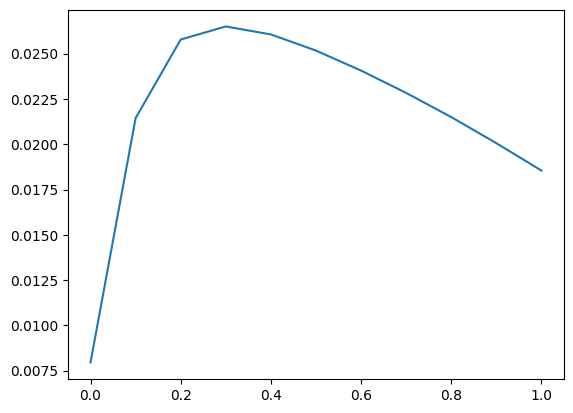

In [10]:
file_path = "./adr_results/moving_surface_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['specie0'])

We can now also repeat the positivity preserving experiment explained in [the positivity preserving notebook](Positivity-ADR) and verify mass preservation

In [17]:
T = 2
t = Parameter(0)
dt = Parameter(0.01)

simulation_pp = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T)

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0, 0, 0))

A = CF((1, 0, 0,\
                0, 1, 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0, 0, 0))
phi, inv_phi, w_phi, detJ, n_ex = sphere_transformation(A, B, t)
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))

simulation_pp.AddMotion(function = displ_ex, domain = '.*')

solver_pp = ADRSolver(linear = True)
simulation_pp.AddSolver(solver_pp)

b_pp = P_ex*CF((0.1,0,-0.1))
d_pp = CF(0.0)
u0 = exp(-4*(x**2+y**2))
Draw(u0, mesh)
Fflux = CF((0,0,0))
Fneu_b = {'bottom': Fflux}
solver_pp.AddSpecie(VorB = BND,
                advection = b_pp,
                u0 = u0,
                Fneu_b = Fneu_b,
                MP = True)

simulation_pp.run()

print('Computed solution')
solver_pp.draw_solution()

mass0 = Integrate(u0, mesh, BND, order = 3)
mesh.SetDeformation(simulation_pp.data['dX'])
mass_end = Integrate(solver_pp.get_solution(), mesh, BND, order = 3)
mesh.UnsetDeformation()

print('Relative mass error: ', (mass_end-mass0)/mass0)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

no more timer available (lff_from_py), reusing last one


Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Relative mass error:  -3.880599379845263e-05
